In [43]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


task 1 

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [45]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Task 2: Missing Value Strategy

In [46]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df = df.drop(columns=['Cabin'], errors='ignore')

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

task 3

In [47]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]
outliers.shape

(116, 11)

In [48]:
df_no_outliers = df[(df['Fare'] >= lower) & (df['Fare'] <= upper)]

print("Original shape:", df.shape)
print("After removing outliers:", df_no_outliers.shape)

Original shape: (891, 11)
After removing outliers: (775, 11)


Outliers in the Fare column were detected using the IQR method.
A total of 116 extreme values were identified and removed.
Removing outliers helps improve model stability.

In [49]:
df = df_no_outliers
df.shape

(775, 11)

Task 4: Normalization

In [50]:
from sklearn.preprocessing import MinMaxScaler

numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

scaler = MinMaxScaler()

df_minmax = df.copy()
df_minmax[numeric_cols] = scaler.fit_transform(df_minmax[numeric_cols])

df_minmax.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,0.271174,0.2,0.0,A/5 21171,0.111538,S
2,3,1,3,"Heikkinen, Miss. Laina",female,0.321438,0.0,0.0,STON/O2. 3101282,0.121923,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.434531,0.2,0.0,113803,0.816923,S
4,5,0,3,"Allen, Mr. William Henry",male,0.434531,0.0,0.0,373450,0.123846,S
5,6,0,3,"Moran, Mr. James",male,0.346569,0.0,0.0,330877,0.130128,Q


In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_zscore = df.copy()
df_zscore[numeric_cols] = scaler.fit_transform(df_zscore[numeric_cols])

df_zscore.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,-0.528321,0.625606,-0.433718,A/5 21171,-0.779117,S
2,3,1,3,"Heikkinen, Miss. Laina",female,-0.215182,-0.486423,-0.433718,STON/O2. 3101282,-0.729373,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.489381,0.625606,-0.433718,113803,2.599828,S
4,5,0,3,"Allen, Mr. William Henry",male,0.489381,-0.486423,-0.433718,373450,-0.720161,S
5,6,0,3,"Moran, Mr. James",male,-0.058613,-0.486423,-0.433718,330877,-0.690071,Q


Min-Max normalization scales values between 0 and 1.
Z-score standardization centers data around 0 with standard deviation 1.

Task 5 (PCA)

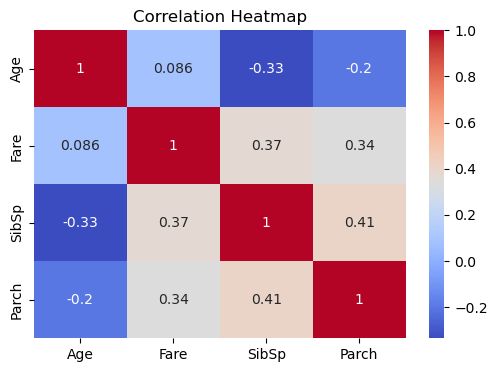

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [53]:
from sklearn.decomposition import PCA

X = df[numeric_cols]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.55024119 0.44660484]


PCA was applied because the numerical features showed moderate correlation.

The first principal component explains approximately 55% of the variance,
while the second explains about 44%.

Together, they capture nearly all of the dataset’s variance (~99%),
indicating that dimensionality reduction is effective.